Question 02

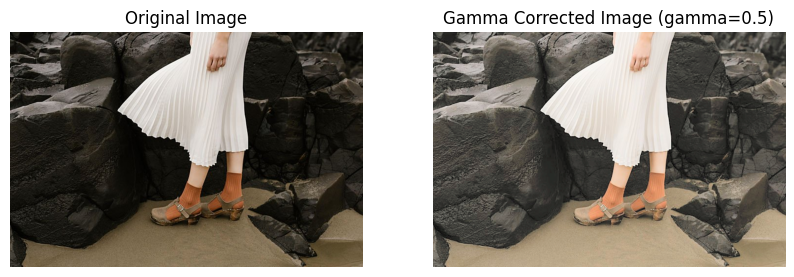

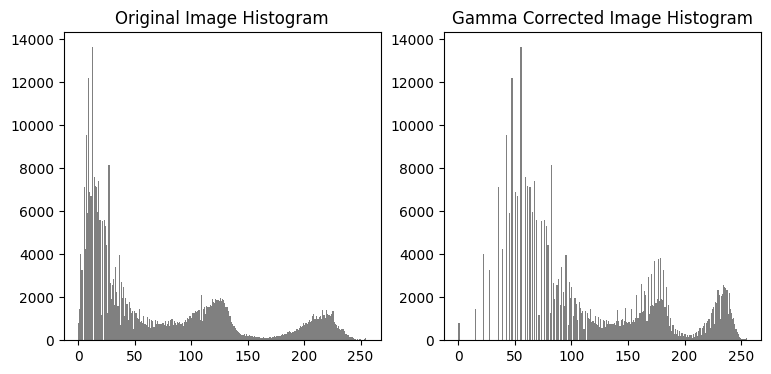

In [10]:
#Question 2 a and b parts

from turtle import color

import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

f = cv.imread('highlights_and_shadows.jpg')
assert f is not None, "Image not found"

#convert to Lab color space
lab = cv.cvtColor(f, cv.COLOR_BGR2LAB)

# Split the Lab image into its channels
l_channel, a_channel, b_channel = cv.split(lab)

# Normalize the L channel to [0,1]
l_norm = l_channel / 255.0

# apply gamma correction with gamma=0.5
gamma = 0.5
l_gamma = np.power(l_norm, gamma)

# Convert back to [0,255]
l_gamma_out = (l_gamma * 255).astype(np.uint8)

#merge and convert back to RGB
lab_gamma = cv.merge((l_gamma_out, a_channel, b_channel))
rgb_gamma = cv.cvtColor(lab_gamma, cv.COLOR_LAB2BGR)

#show results
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.title("Original Image")
plt.imshow(cv.cvtColor(f, cv.COLOR_BGR2RGB))
plt.axis('off')

plt.subplot(1,2,2)
plt.title("Gamma Corrected Image (gamma=0.5)")
plt.imshow(cv.cvtColor(rgb_gamma, cv.COLOR_BGR2RGB))
plt.axis('off')

plt.show()

#histograms

plt.figure(figsize=(9,4))
plt.subplot(1,2,1)
plt.title("Original Image Histogram")
plt.hist(l_channel.ravel(), bins=256, range=(0,255), color='gray')

plt.subplot(1,2,2)
plt.title("Gamma Corrected Image Histogram")
plt.hist(l_gamma_out.ravel(), bins=256, range=(0,255), color='gray')

plt.show()
